Import

In [41]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("pt4/CB_errors.csv", delimiter=',', skiprows=1)
internal_modes = data[:, 0]
reduction_times = data[:, 1]
eigenproblem_times = data[:, 2]
errors = data[:, 3:9]
CB_frequencies = data[:, 9:15]
GI_frequencies = data[0, 15:21]
GI_errors = data[0, 21:27]
full_frequencies = data[0, 27:33]

cutting to a given number of modes

In [42]:
n_modes_max = 20


internal_modes = internal_modes[:n_modes_max]
reduction_times = reduction_times[:n_modes_max]
eigenproblem_times = eigenproblem_times[:n_modes_max]
errors = errors[:n_modes_max, :]

plot Time of matrix building

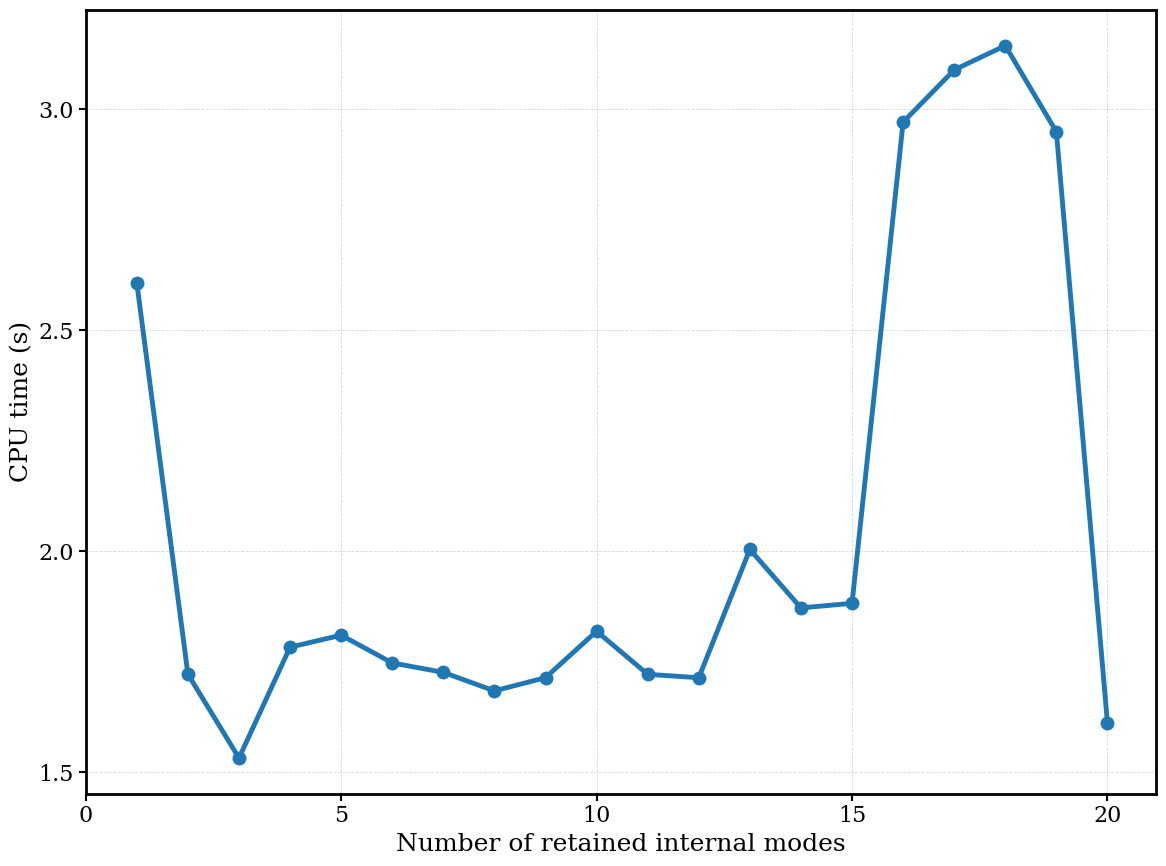

In [43]:


# use latex
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.tick_params(axis='both', which='major',
                labelsize=16, width=1.5, length=5)
plt.tick_params(axis='both', which='minor',
                labelsize=12, width=1, length=3)


plt.plot(internal_modes, reduction_times, marker='o', label='Reduction time')
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Number of retained internal modes')
plt.ylabel('CPU time (s)')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()

plot time eigen problem solving


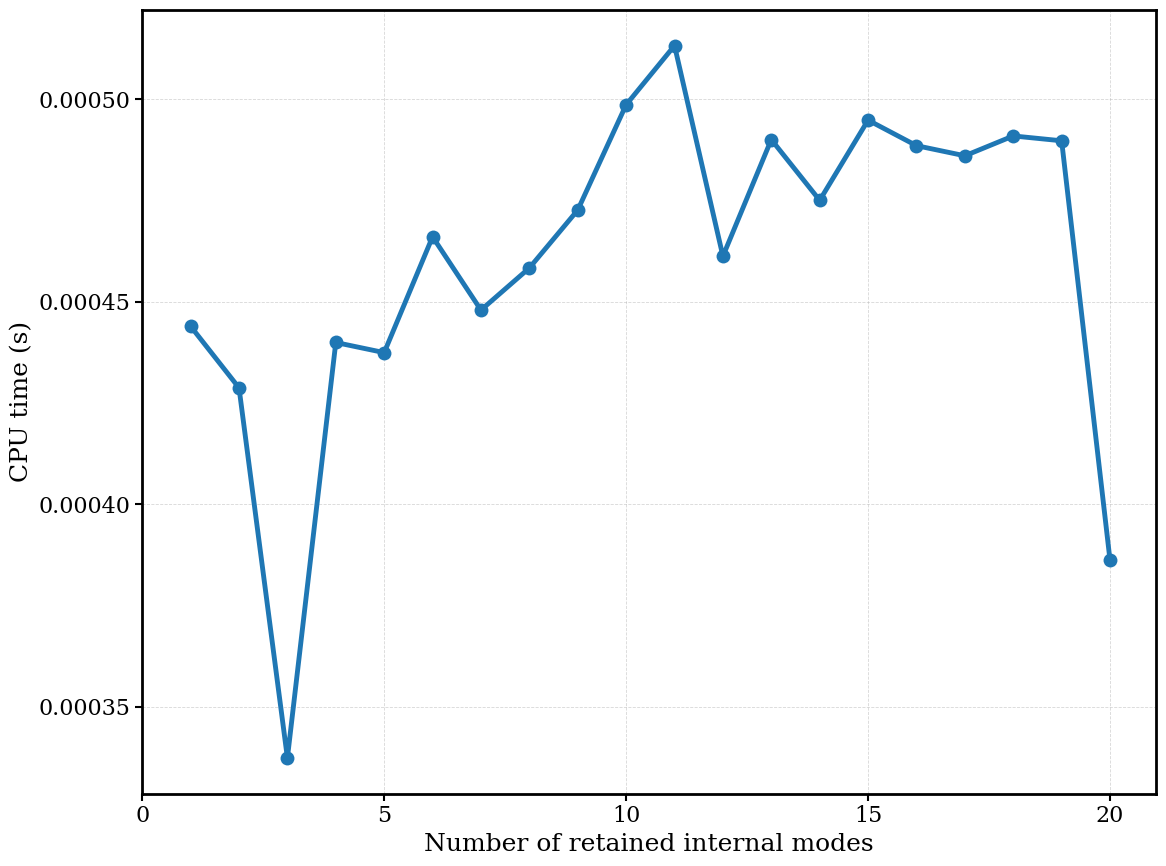

In [44]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.tick_params(axis='both', which='major',
                labelsize=16, width=1.5, length=5)
plt.tick_params(axis='both', which='minor',
                labelsize=12, width=1, length=3)


plt.plot(internal_modes, eigenproblem_times, marker='o')
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Number of retained internal modes')
plt.ylabel('CPU time (s)')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()

Convergence of errors 

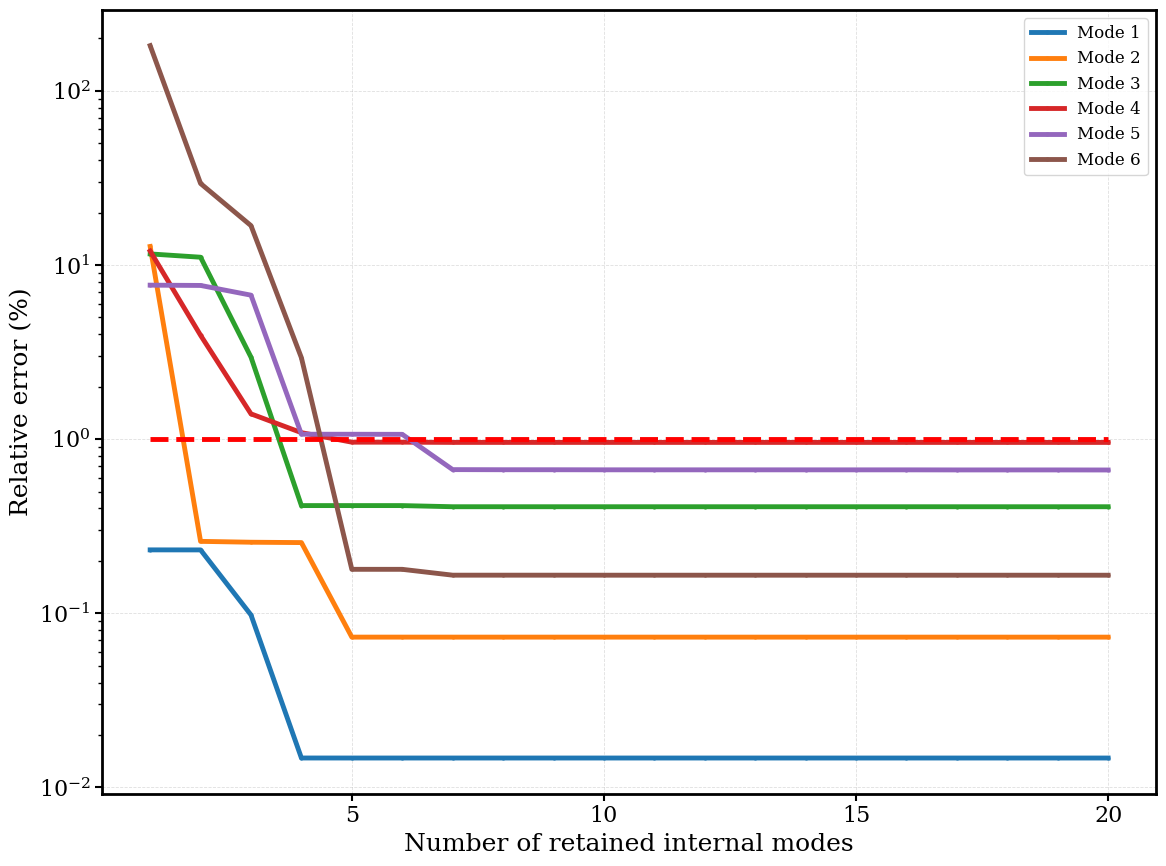

In [45]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.tick_params(axis='both', which='major',
                labelsize=16, width=1.5, length=5)
plt.tick_params(axis='both', which='minor',
                labelsize=12, width=1, length=3)

plt.xticks([0, 5, 10, 15, 20])
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
plt.xlabel('Number of retained internal modes')
plt.ylabel('Relative error (%)')


for i in range(6):
    plt.plot(internal_modes, errors[:, i],
             marker='o', markersize=3,  label=f'Mode {i+1}')
plt.yscale('log')
plt.legend(loc='upper right', frameon=True)

plt.hlines(1, colors='r', linestyles='dashed',
           label='1% error', xmin=1, xmax=internal_modes[-1])


plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig("pt4/CB_errors.pdf", bbox_inches='tight')
plt.show()

Computation times , full vs GI vs CB

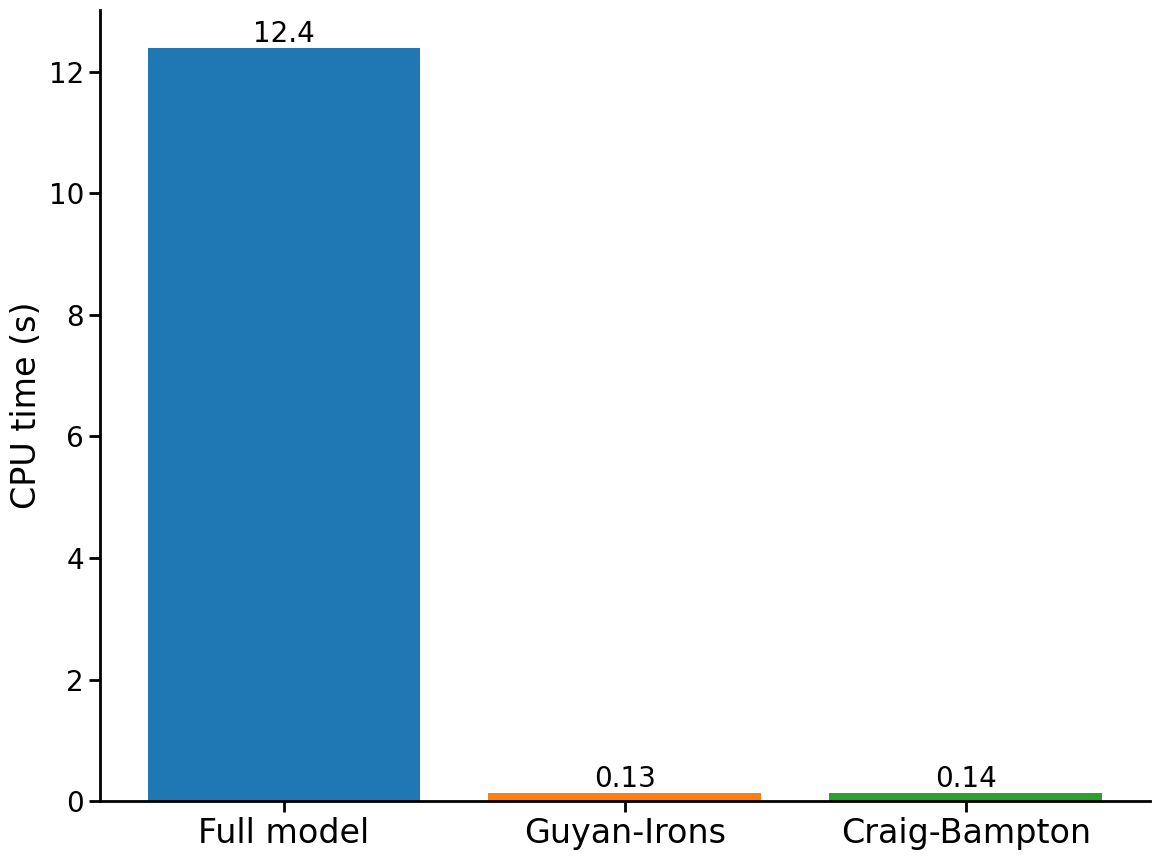

In [46]:
import numpy as np
import matplotlib.pyplot as plt

times = np.array([12.4, 0.13, 0.14])
labels = ['Full model', 'Guyan-Irons', 'Craig-Bampton']

# Normalize to Full model
rel_times = times

slide_params = {
    'font.size': 20,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 20,
    'lines.linewidth': 3.5,
    'lines.markersize': 8,
    'axes.linewidth': 2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 8.0,
    'ytick.major.size': 8.0,
    'font.family': 'sans-serif',
    'figure.autolayout': True,
    'figure.figsize': (12, 9),
}
plt.rcParams.update(slide_params)

fig, ax = plt.subplots()
bars = ax.bar(labels, rel_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('CPU time (s)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Annotate values as percentages
for bar, rel in zip(bars, rel_times):
    ax.text(bar.get_x() + bar.get_width()/2, rel,
            f'{rel}', ha='center', va='bottom', fontsize=20)

plt.savefig("presentation/pt4CPUlinear.svg", transparent=True)

Evolution frequencies vs modes

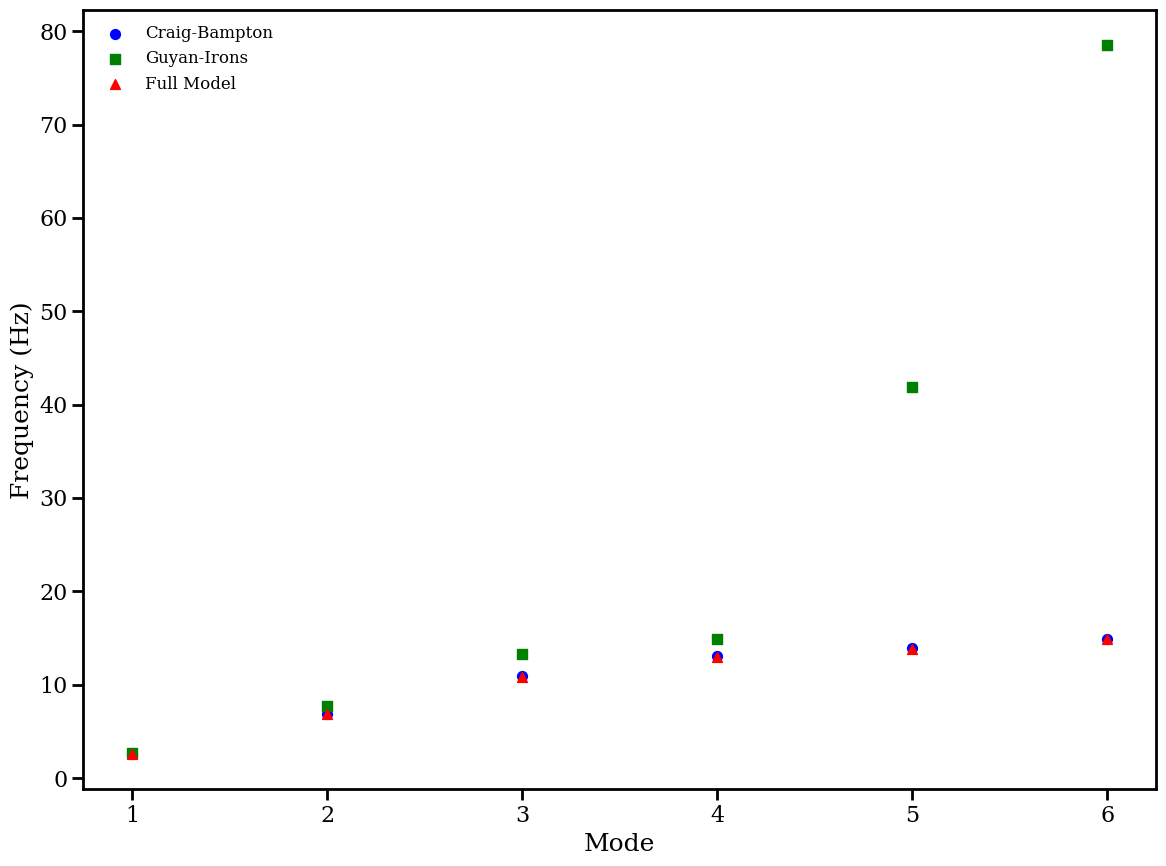

In [47]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})
modes = np.arange(1, 7)
CB_freq_7modes = CB_frequencies[6, :]

plt.scatter(modes, CB_freq_7modes, marker='o', s=50,
            color='blue', label='Craig-Bampton')
plt.scatter(modes, GI_frequencies, marker='s', s=60,
            color='green', label='Guyan-Irons')
plt.scatter(modes, full_frequencies, marker='^',
            s=50, color='red', label='Full Model')


plt.xlabel("Mode")
plt.ylabel("Frequency (Hz)")
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig("pt4/full_GI_CB_freq.pdf", dpi=300)

Errors of both methods

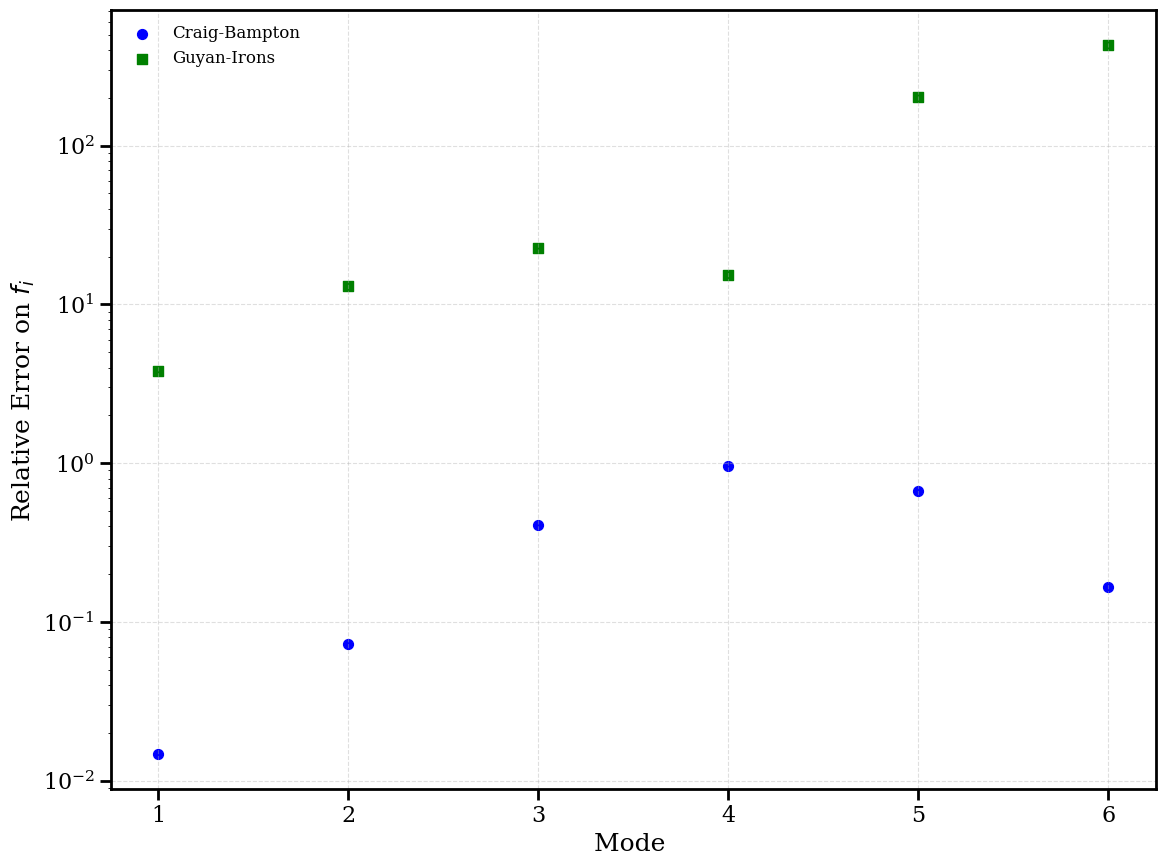

In [48]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})
modes = np.arange(1, 7)
CB_errors_7modes = errors[6, :]

plt.scatter(modes, CB_errors_7modes, marker='o',
            s=50, color='blue', label='Craig-Bampton')
plt.scatter(modes, GI_errors, marker='s', s=60,
            color='green', label='Guyan-Irons')
plt.yscale('log')
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()

plt.xlabel("Mode ")
plt.ylabel(r"Relative Error on $f_i$ ")
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig("pt4/GI_CB_errors.pdf", dpi=300)

Partie b : time integration


In [49]:
def rms_error(q_full, q_red, t):

    dt = t[1] - t[0]
    num = np.trapz((q_red - q_full)**2, dx=dt)
    den = np.trapz(q_full**2, dx=dt)
    return 100.0 * np.sqrt(num / den)


def peak_error(q_full, q_red):
    return abs(np.max(q_red) - np.max(q_full))/np.max(q_full) * 100

peak error GI 6.832
peak error CB 2.285
rms error GI 50.791
rms error CB 9.956


C:\Users\tbeau\AppData\Local\Temp\ipykernel_36272\4218182694.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz((q_red - q_full)**2, dx=dt)
C:\Users\tbeau\AppData\Local\Temp\ipykernel_36272\4218182694.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(q_full**2, dx=dt)


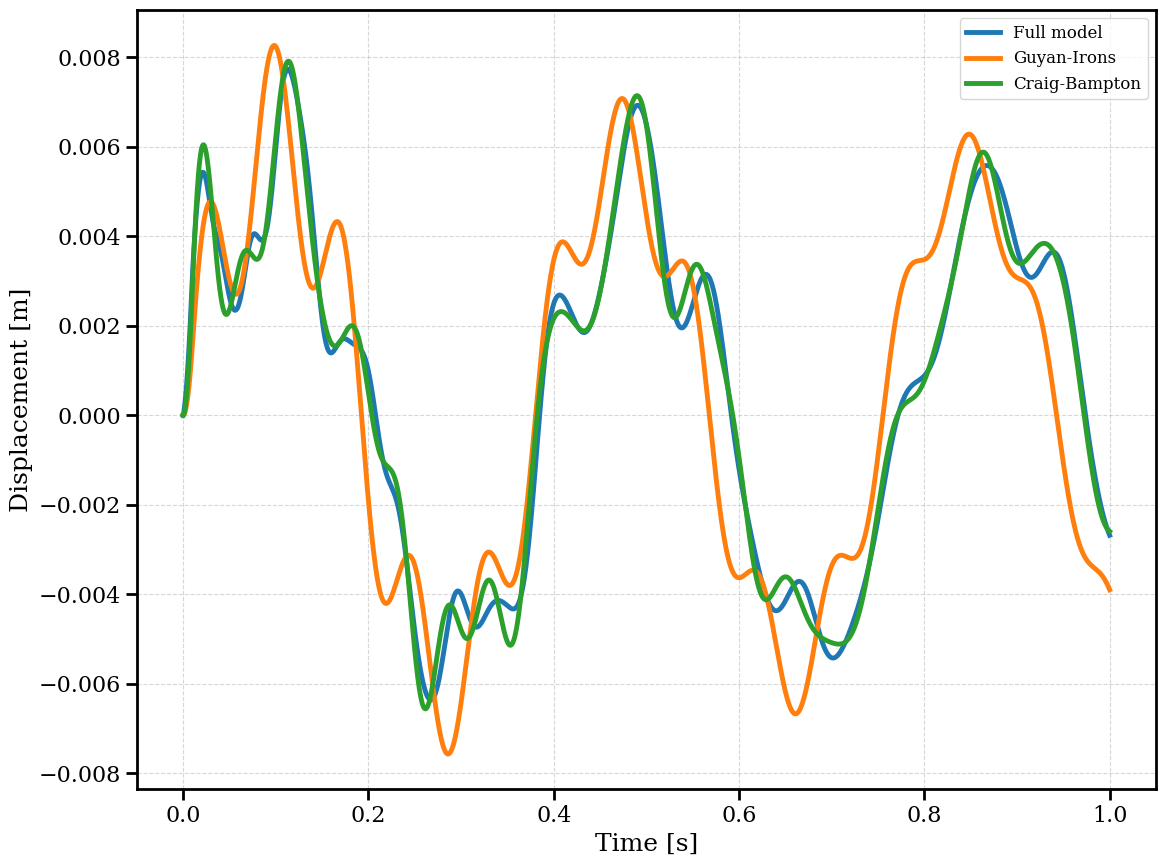

In [50]:
data = np.loadtxt("pt4/time_integ.csv", delimiter=',', skiprows=1)
t = data[:, 0]
q_full = data[:, 1]
q_GI = data[:, 2]
q_CB = data[:, 3]


idx = np.where((t >= 0) & (t <= 1))[0]

t = t[idx]
q_full = q_full[idx]
q_GI = q_GI[idx]
q_CB = q_CB[idx]


peak_error_GI = peak_error(q_full, q_GI)
peak_error_CB = peak_error(q_full, q_CB)

print(f"peak error GI {peak_error_GI:.3f}")
print(f"peak error CB {peak_error_CB:.3f}")


rms_GI = rms_error(q_full, q_GI, t)
rms_CB = rms_error(q_full, q_CB, t)

print(f"rms error GI {rms_GI:.3f}")
print(f"rms error CB {rms_CB:.3f}")


plt.plot(t, q_full, label='Full model')
plt.plot(t, q_GI, label='Guyan-Irons')
plt.plot(t, q_CB, label='Craig-Bampton')
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.legend(frameon=True)
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.savefig("pt4/TimeInteg_0to1.pdf", dpi=300)
plt.show()

dft of the displacements

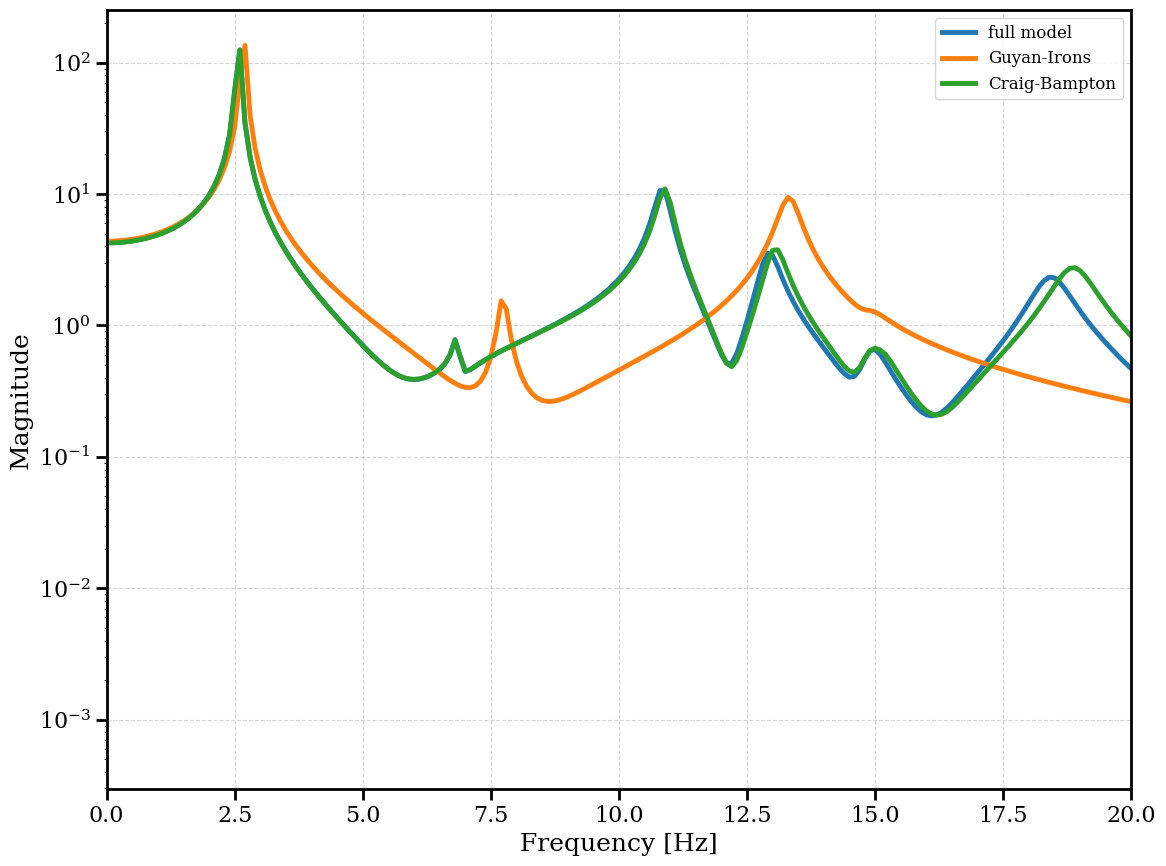

In [51]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})


data = np.loadtxt("pt4/time_integ.csv", delimiter=',', skiprows=1)
t = data[:, 0]
q_full = data[:, 1]
q_GI = data[:, 2]
q_CB = data[:, 3]

idx = np.where((t >= 0) & (t <= 10))[0]

t = t[idx]
q_full = q_full[idx]
q_GI = q_GI[idx]
q_CB = q_CB[idx]

N = q_full.size


T = t[-1] - t[0]                    # total duration
dt = t[1] - t[0]                    # sampling period
fs = 1/dt                           # sampling frequency


Q_full = np.fft.rfft(q_full)
Q_GI = np.fft.rfft(q_GI)
Q_CB = np.fft.rfft(q_CB)

freqs = np.fft.rfftfreq(N, dt)             # matching frequency axis


# plot pre-processing : cut to avoid the 0 in f = 0, take absolute value
Q_full = np.abs(Q_full[1:])
Q_GI = np.abs(Q_GI[1:])
Q_CB = np.abs(Q_CB[1:])
freqs = freqs[1:]


plt.plot(freqs, Q_full, label="full model")
plt.plot(freqs, Q_GI, label="Guyan-Irons")
plt.plot(freqs, Q_CB, label="Craig-Bampton")
plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, 20)

plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.savefig("pt4/TimeIntegDFT_0to1.pdf", dpi=300)
plt.show()

## Part  3 : Plots for study convergence of time step

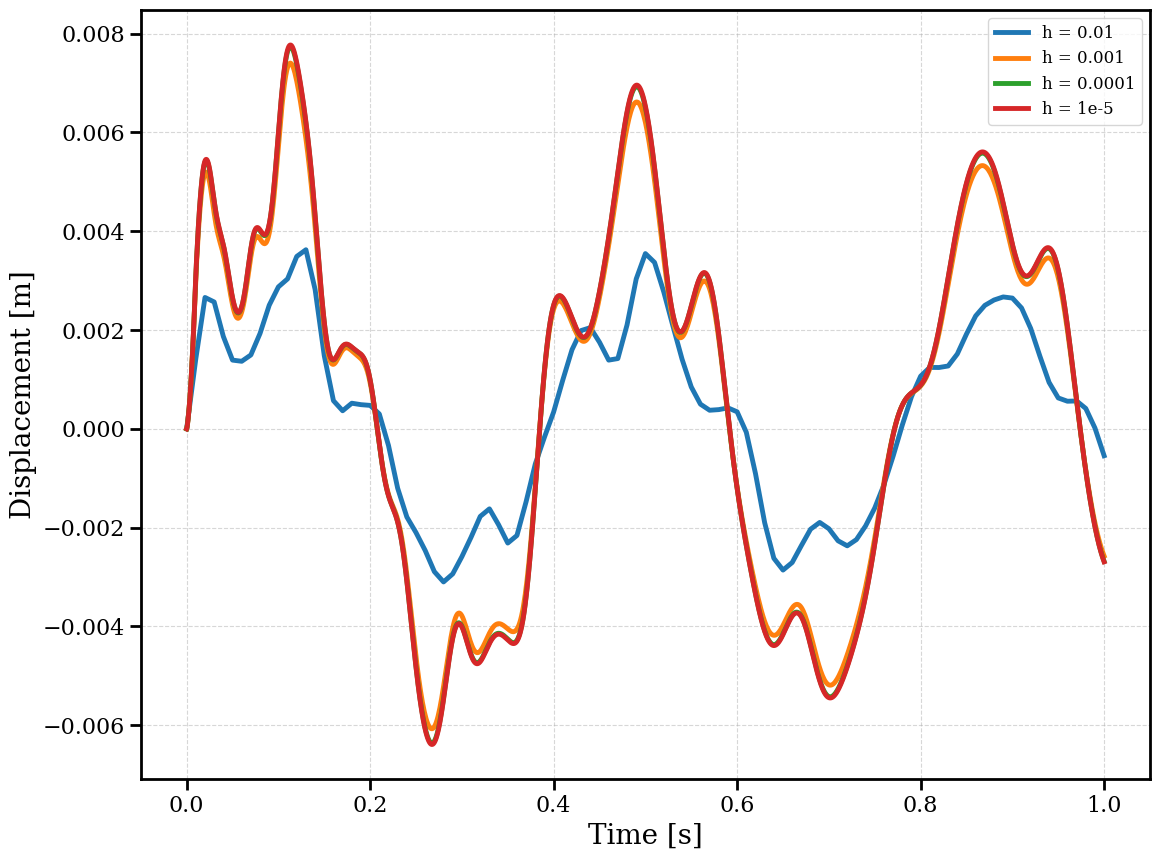

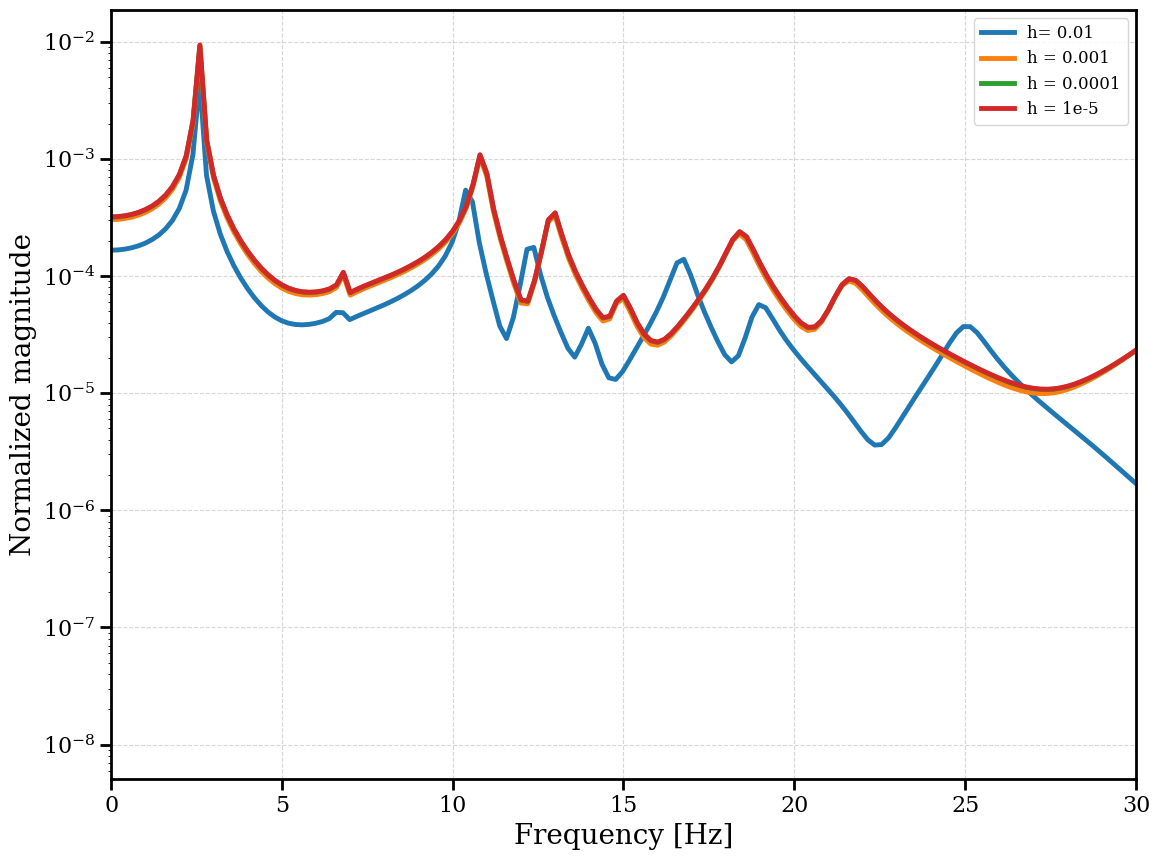

In [52]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})

"""" 1 : Import data"""
data1 = np.loadtxt("pt3/time_integ_T5_h0.01.csv",
                   delimiter=',', skiprows=1)  # T = 5, h = 0.01
t1 = data1[:, 0]
q1 = data1[:, 1]


data2 = np.loadtxt("pt3/time_integ_T5_h0.001.csv", delimiter=',', skiprows=1)
t2 = data2[:, 0]
q2 = data2[:, 1]

data3 = np.loadtxt("pt3/time_integ_T5_h0.0001.csv", delimiter=',', skiprows=1)
t3 = data3[:, 0]
q3 = data3[:, 1]

data4 = np.loadtxt("pt3/time_integ_T5_h1e-05.csv", delimiter=',', skiprows=1)
t4 = data4[:, 0]
q4 = data4[:, 1]

""" 2 : do the DFT """
# dft done on the full integ period
N1 = q1.size
T1 = t1[-1] - t1[0]
dt1 = t1[1] - t1[0]
Q1 = np.abs(np.fft.rfft(q1)) * dt1
freqs1 = np.fft.rfftfreq(N1, dt1)

N2, dt2 = q2.size, t2[1] - t2[0]
Q2 = np.abs(np.fft.rfft(q2)) * dt2
freqs2 = np.fft.rfftfreq(N2, dt2)

N3, dt3 = q3.size, t3[1] - t3[0]
Q3 = np.abs(np.fft.rfft(q3)) * dt3
freqs3 = np.fft.rfftfreq(N3, dt3)

N4, dt4 = q4.size, t4[1] - t4[0]
Q4 = np.abs(np.fft.rfft(q4)) * dt4
freqs4 = np.fft.rfftfreq(N4, dt4)

""" 3 : cut tim1e to 1 second for time response"""
time_cut_low = 0
time_cut_high = 1
idx1 = np.where((t1 >= time_cut_low) & (t1 <= time_cut_high))[0]
idx2 = np.where((t2 >= time_cut_low) & (t2 <= time_cut_high))[0]
idx3 = np.where((t3 >= time_cut_low) & (t3 <= time_cut_high))[0]
idx4 = np.where((t4 >= time_cut_low) & (t4 <= time_cut_high))[0]

t1_cut = t1[idx1]
q1_cut = q1[idx1]

t2_cut = t2[idx2]
q2_cut = q2[idx2]

t3_cut = t3[idx3]
q3_cut = q3[idx3]

t4_cut = t4[idx4]
q4_cut = q4[idx4]

""" 4 : plot time response"""
plt.plot(t1_cut, q1_cut, label='h = 0.01')
plt.plot(t2_cut, q2_cut, label='h = 0.001')
plt.plot(t3_cut, q3_cut, label='h = 0.0001')
plt.plot(t4_cut, q4_cut, label='h = 1e-5')


plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
# plt.savefig("pt3/timeStepConvergence.pdf", dpi=300)
plt.show()


""" 5 : plot the DFT """
plt.plot(freqs1, Q1, label="h= 0.01")
plt.plot(freqs2, Q2, label='h = 0.001')
plt.plot(freqs3, Q3, label='h = 0.0001')
plt.plot(freqs4, Q4, label='h = 1e-5')


plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized magnitude")
plt.xlim(0, 30)
# plt.vlines([2.573,6.844,10.855,12.916,13.866,14.877], colors='r', linestyles='dashed', linewidth = 1,label=r' 6 1$^{st}$ natural frequencies', ymin=0, ymax=1e-1)
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
# plt.savefig("pt3/timeStepConvergenceDFT.pdf", dpi=300)
plt.show()

# numerically damped systems

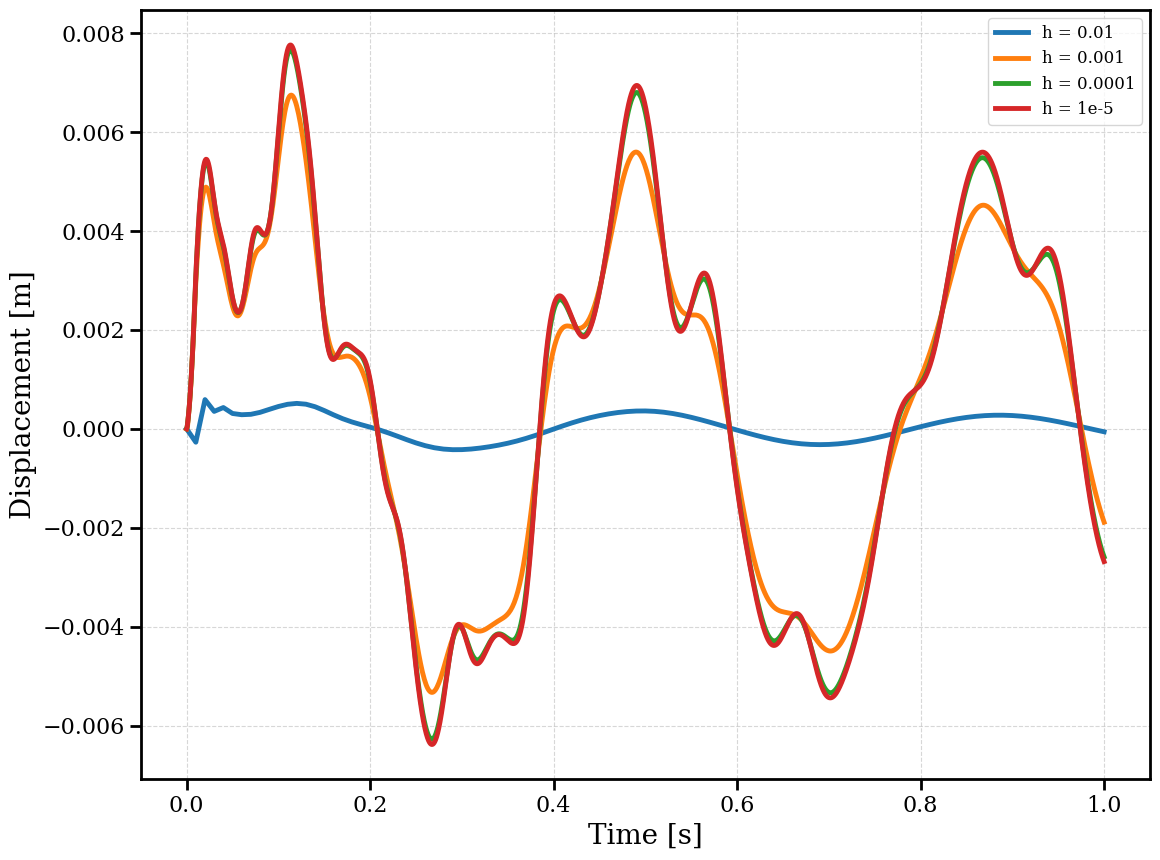

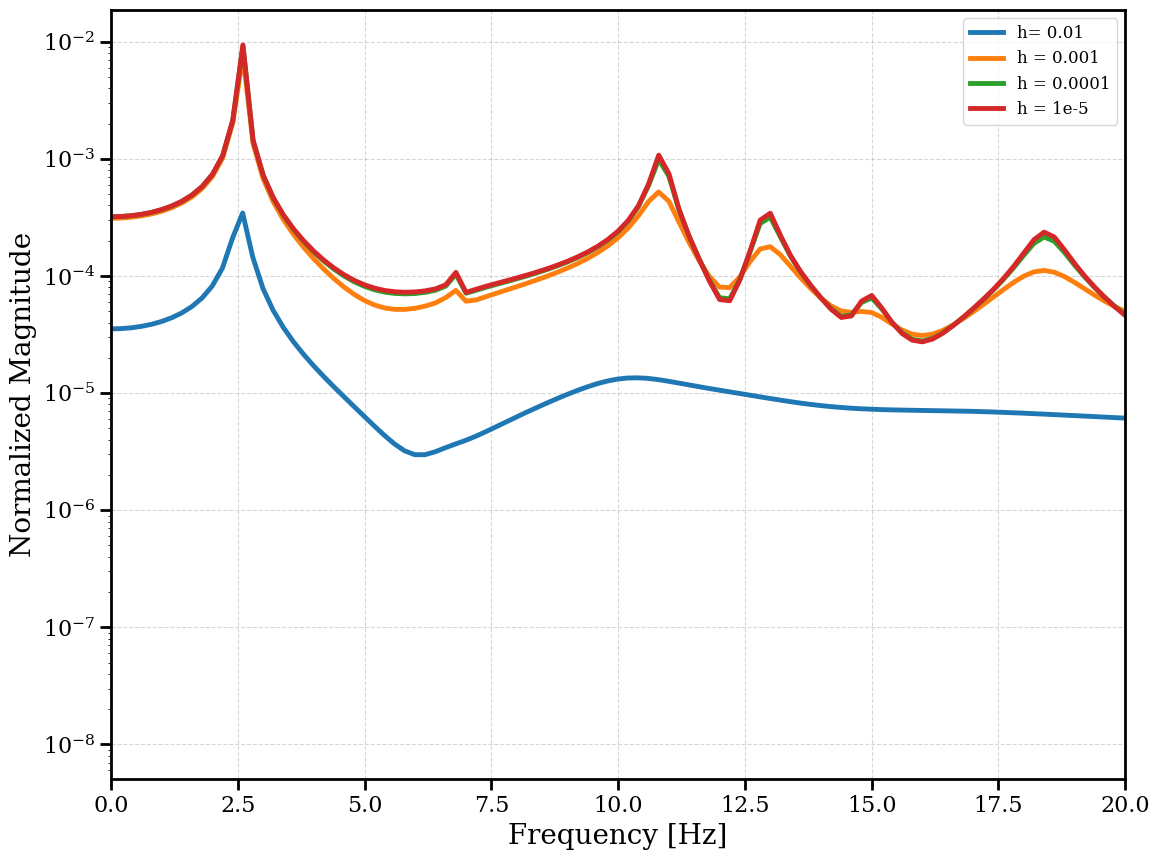

In [53]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    # ou ["DejaVu Serif"], ["STIX"], etc.
    "font.serif": ["Times New Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})

"""" 1 : Import data"""
data1 = np.loadtxt("pt3/time_integ_T5_h0.01_damping.csv",
                   delimiter=',', skiprows=1)  # T = 5, h = 0.01
t1 = data1[:, 0]
q1 = data1[:, 1]


data2 = np.loadtxt("pt3/time_integ_T5_h0.001_damping.csv",
                   delimiter=',', skiprows=1)
t2 = data2[:, 0]
q2 = data2[:, 1]

data3 = np.loadtxt("pt3/time_integ_T5_h0.0001_damping.csv",
                   delimiter=',', skiprows=1)
t3 = data3[:, 0]
q3 = data3[:, 1]

data4 = np.loadtxt("pt3/time_integ_T5_h1e-05_damping.csv",
                   delimiter=',', skiprows=1)
t4 = data4[:, 0]
q4 = data4[:, 1]

""" 2 : do the DFT """
# dft done on the full integ period
N1 = q1.size
T1 = t1[-1] - t1[0]
dt1 = t1[1] - t1[0]
Q1 = np.abs(np.fft.rfft(q1)) * dt1
freqs1 = np.fft.rfftfreq(N1, dt1)

N2, dt2 = q2.size, t2[1] - t2[0]
Q2 = np.abs(np.fft.rfft(q2)) * dt2
freqs2 = np.fft.rfftfreq(N2, dt2)

N3, dt3 = q3.size, t3[1] - t3[0]
Q3 = np.abs(np.fft.rfft(q3)) * dt3
freqs3 = np.fft.rfftfreq(N3, dt3)

N4, dt4 = q4.size, t4[1] - t4[0]
Q4 = np.abs(np.fft.rfft(q4)) * dt4
freqs4 = np.fft.rfftfreq(N4, dt4)

""" 3 : cut time to 1 second for time response"""
time_cut_low = 0
time_cut_high = 1
idx1 = np.where((t1 >= time_cut_low) & (t1 <= time_cut_high))[0]
idx2 = np.where((t2 >= time_cut_low) & (t2 <= time_cut_high))[0]
idx3 = np.where((t3 >= time_cut_low) & (t3 <= time_cut_high))[0]
idx4 = np.where((t4 >= time_cut_low) & (t4 <= time_cut_high))[0]

t1_cut = t1[idx1]
q1_cut = q1[idx1]

t2_cut = t2[idx2]
q2_cut = q2[idx2]

t3_cut = t3[idx3]
q3_cut = q3[idx3]

t4_cut = t4[idx4]
q4_cut = q4[idx4]

""" 4 : plot time response"""
plt.plot(t1_cut, q1_cut, label='h = 0.01')
plt.plot(t2_cut, q2_cut, label='h = 0.001')
plt.plot(t3_cut, q3_cut, label='h = 0.0001')
plt.plot(t4_cut, q4_cut, label='h = 1e-5')


plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.savefig("pt3/timeStepConvergence_damping.pdf", dpi=300)
plt.show()


""" 5 : plot the DFT """
plt.plot(freqs1, Q1, label="h= 0.01")
plt.plot(freqs2, Q2, label='h = 0.001')
plt.plot(freqs3, Q3, label='h = 0.0001')
plt.plot(freqs4, Q4, label='h = 1e-5')


plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Magnitude")
plt.xlim(0, 20)

plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.savefig("pt3/timeStepConvergenceDFT_damping.pdf", dpi=300)
plt.show()

Code Plots for presentation

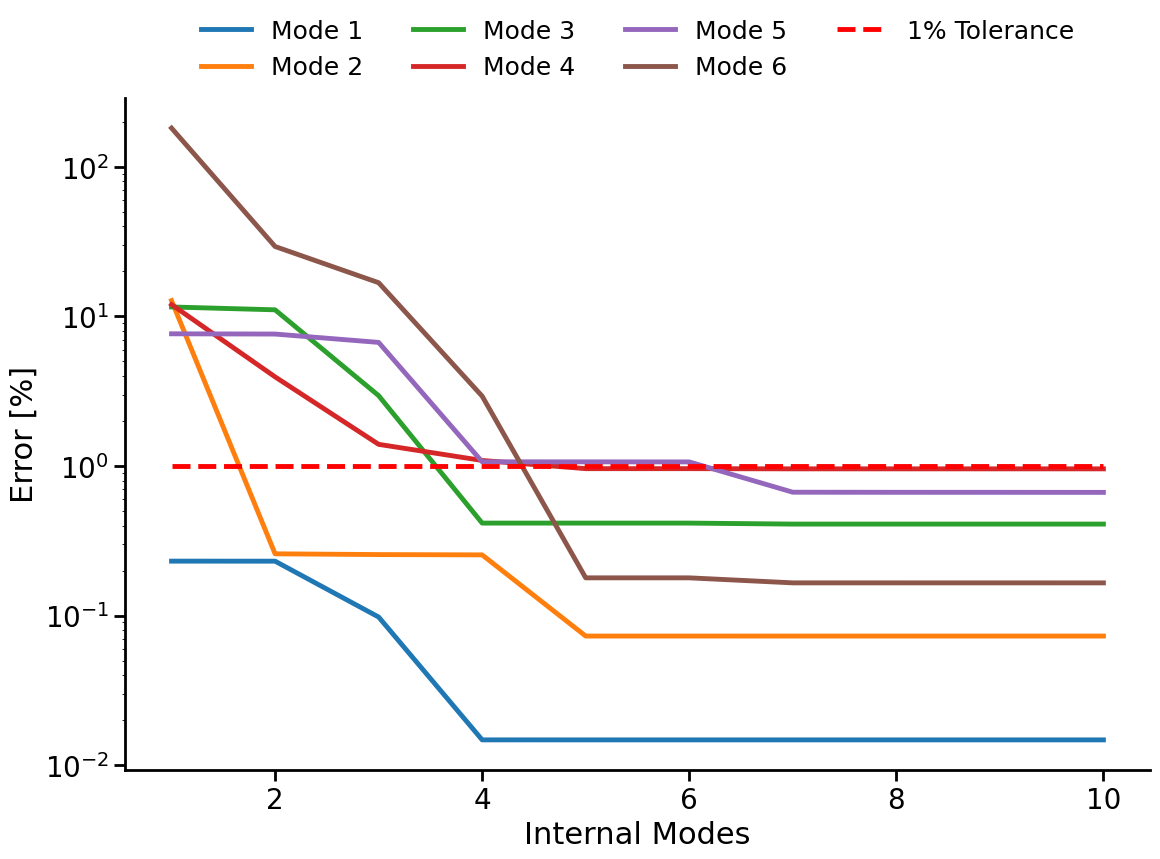

In [ ]:

slide_params = {
    # Text Sizes (Large for visibility)
    'font.size': 20,           # General default
    'axes.labelsize': 22,      # x and y labels
    'axes.titlesize': 24,      # Title
    'xtick.labelsize': 20,     # Tick numbers
    'ytick.labelsize': 20,
    'legend.fontsize': 18,     # Legend text

    # Line & Marker Geometries (Thick for projectors)
    'lines.linewidth': 3.5,    # Thicker data lines
    'lines.markersize': 10,    # Much larger markers (default was too small)
    'lines.markeredgewidth': 0,  # Remove marker outline for cleaner look

    # Structural Geometries
    'axes.linewidth': 2.0,     # Thicker spines (box)
    'xtick.major.width': 2.0,  # Thicker ticks
    'ytick.major.width': 2.0,
    'xtick.major.size': 8.0,   # Longer ticks
    'ytick.major.size': 8.0,

    # Slide Aesthetics
    'font.family': 'sans-serif',  # Sans-serif is more legible on slides than serif
    'figure.autolayout': True,   # Similar to tight_layout
    'figure.figsize': (12, 9),   # 16:9 Aspect Ratio by default
}

# Apply the parameters globally
plt.rcParams.update(slide_params)


# --- 3. Plotting Logic ---
fig, ax = plt.subplots()  # Note: figsize is now handled by params

# Generate distinct colors for 6 modes to avoid "spaghetti plot" confusion
# colors = plt.cm.viridis(np.linspace(0, 0.9, 6))

for i in range(6):
    ax.plot(internal_modes[:10], errors[:, i][:10],
            marker='o',      # Marker shape
            label=f'Mode {i+1}')

# Threshold Line
# Note: specific overrides (like linestyle) can still be done here
ax.hlines(1, xmin=internal_modes[0], xmax=10,
          colors='r', linestyles='--', label='1% Tolerance')

# Labels & Scales
ax.set_xlabel('Internal Modes')   # Fontsize is auto-set by params
ax.set_ylabel('Error [%]')        # Fontsize is auto-set by params
ax.set_yscale('log')

# Manual Aesthetic Tweaks (Things params can't easily do)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend - Placed horizontally at the top to save vertical space
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=4, frameon=False)

# Save
plt.savefig('presentation/try.svg', transparent=True)
plt.show()

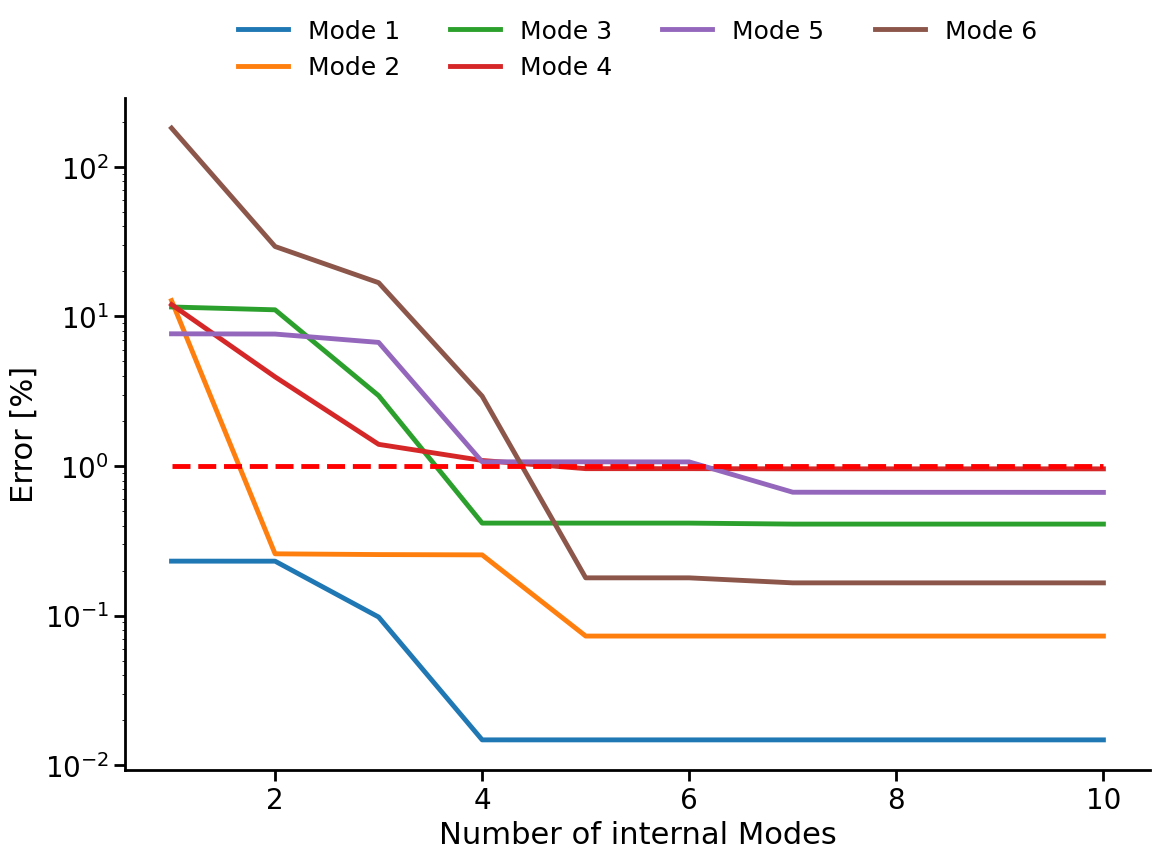

In [55]:
from plotSlides import plotSlides, plotSlidesMulti


data = np.loadtxt("pt4/CB_errors.csv", delimiter=',', skiprows=1)
internal_modes = data[:, 0]

errors = data[:, 3:9]


nb_internal_modes = 10
internal_modes = internal_modes[:nb_internal_modes]
errors = errors[:nb_internal_modes, :]

y = np.zeros((6, nb_internal_modes))

for i in range(6):
    y[i] = errors[:, i]

labels = [f"Mode {i+1}" for i in range(np.shape(errors)[1])]

plotSlidesMulti(internal_modes, y, xLabel='Number of internal Modes',
                yLabel='Error [%]', labels=labels, yScaleLog=True, savePath='presentation/try2', hline=1)

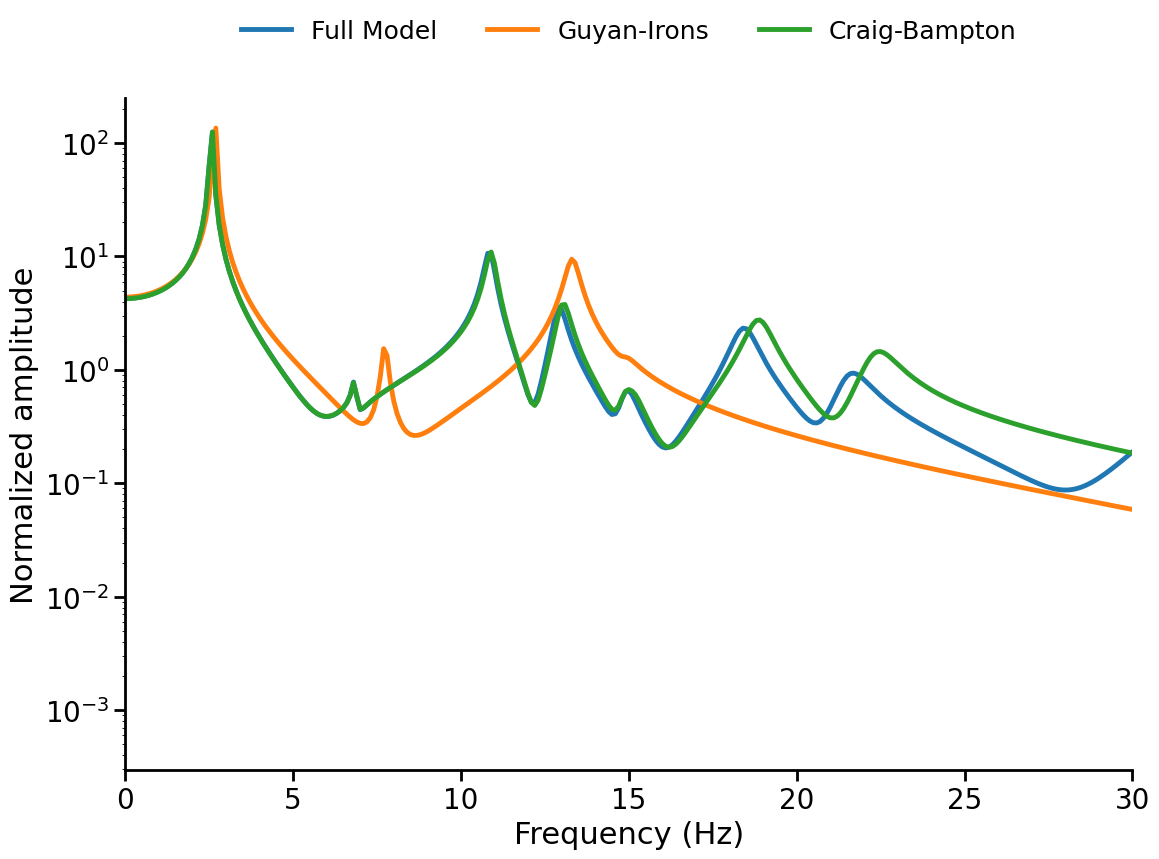

In [56]:
data = np.loadtxt("pt4/time_integ.csv", delimiter=',', skiprows=1)
t = data[:, 0]
q_full = data[:, 1]
q_GI = data[:, 2]
q_CB = data[:, 3]

idx = np.where((t >= 0) & (t <= 10))[0]

t = t[idx]
q_full = q_full[idx]
q_GI = q_GI[idx]
q_CB = q_CB[idx]

N = q_full.size


T = t[-1] - t[0]                    # total duration
dt = t[1] - t[0]                    # sampling period
fs = 1/dt                           # sampling frequency


Q_full = np.fft.rfft(q_full)
Q_GI = np.fft.rfft(q_GI)
Q_CB = np.fft.rfft(q_CB)

freqs = np.fft.rfftfreq(N, dt)             # matching frequency axis


# plot pre-processing : cut to avoid the 0 in f = 0, take absolute value
Q_full = np.abs(Q_full[1:])
Q_GI = np.abs(Q_GI[1:])
Q_CB = np.abs(Q_CB[1:])
freqs = freqs[1:]
labels = ["Full Model", "Guyan-Irons", "Craig-Bampton"]

plotSlidesMulti(freqs, [Q_full, Q_GI, Q_CB], xLabel='Frequency (Hz)',
                yLabel='Normalized amplitude', labels=labels, yScaleLog=True, savePath='presentation/pt4DFT', xlim=30)

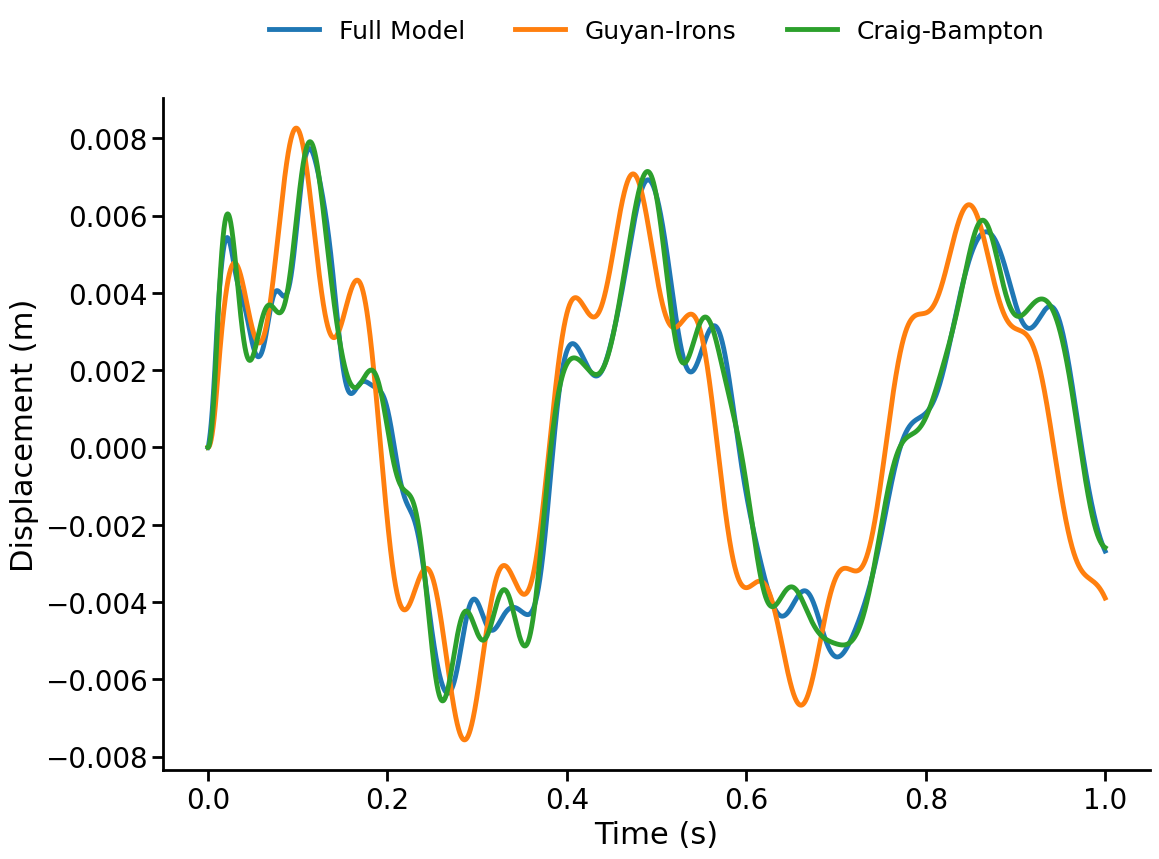

In [57]:
data = np.loadtxt("pt4/time_integ.csv", delimiter=',', skiprows=1)
t = data[:, 0]
q_full = data[:, 1]
q_GI = data[:, 2]
q_CB = data[:, 3]


idx = np.where((t >= 0) & (t <= 1))[0]

t = t[idx]
q_full = q_full[idx]
q_GI = q_GI[idx]
q_CB = q_CB[idx]
labels = ["Full Model", "Guyan-Irons", "Craig-Bampton"]

plotSlidesMulti(t, [q_full, q_GI, q_CB], xLabel='Time (s)',
                yLabel='Displacement (m)', labels=labels, savePath='presentation/pt4_transient')

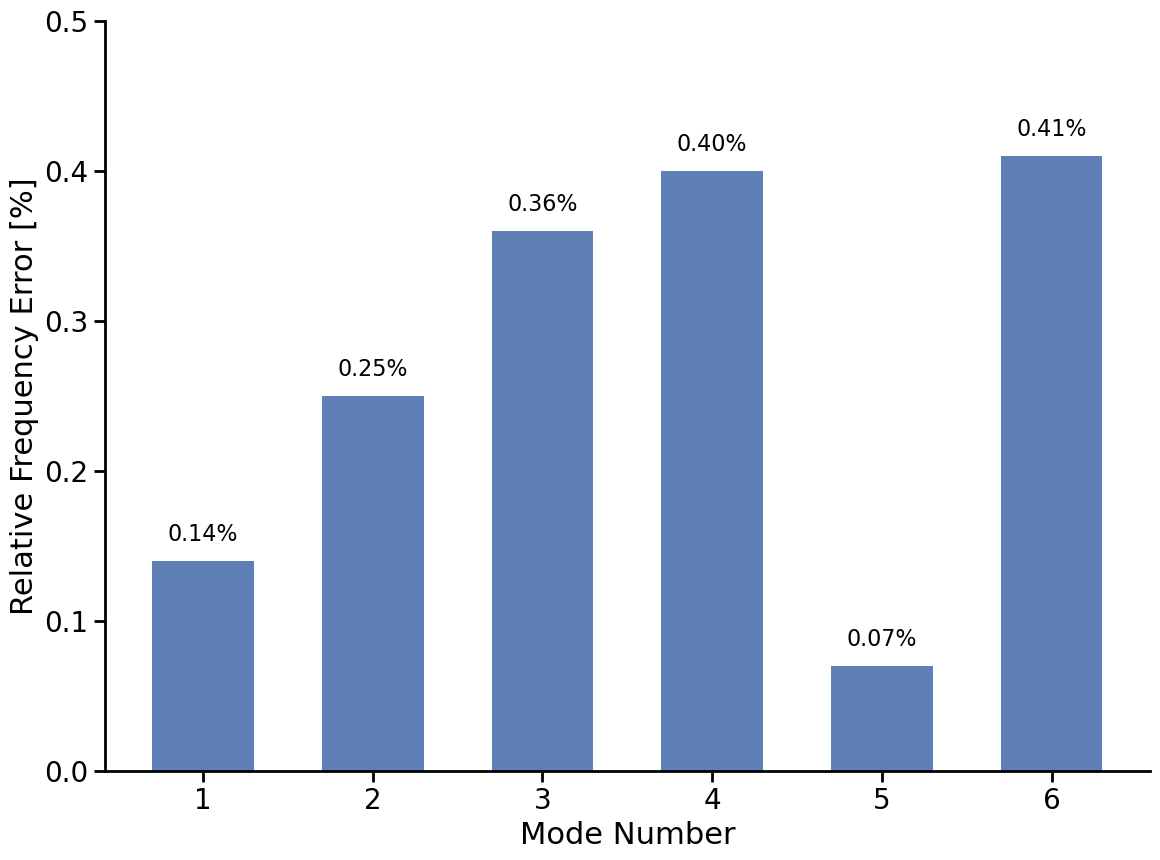

In [59]:
import matplotlib.pyplot as plt
import numpy as np
slide_params = {
    # Text Sizes (Large for visibility)
    'font.size': 20,           # General default
    'axes.labelsize': 22,      # x and y labels
    'axes.titlesize': 24,      # Title
    'xtick.labelsize': 20,     # Tick numbers
    'ytick.labelsize': 20,
    'legend.fontsize': 18,     # Legend text

    # Line & Marker Geometries (Thick for projectors)
    'lines.linewidth': 3.5,    # Thicker data lines
    'lines.markersize': 10,    # Much larger markers (default was too small)
    'lines.markeredgewidth': 0,  # Remove marker outline for cleaner look

    # Structural Geometries
    'axes.linewidth': 2.0,     # Thicker spines (box)
    'xtick.major.width': 2.0,  # Thicker ticks
    'ytick.major.width': 2.0,
    'xtick.major.size': 8.0,   # Longer ticks
    'ytick.major.size': 8.0,

    # Slide Aesthetics
    'font.family': 'sans-serif',  # Sans-serif is more legible on slides than serif
    'figure.autolayout': True,   # Similar to tight_layout
    'figure.figsize': (12, 9),   # 16:9 Aspect Ratio by default
}

# Apply the parameters globally
plt.rcParams.update(slide_params)


# Données de votre Table A
modes = np.array([1, 2, 3, 4, 5, 6])
errors = np.array([0.14, 0.25, 0.36, 0.40, 0.07, 0.41])

fig, ax = plt.subplots()  # Création des barres
bars = plt.bar(modes, errors, color='#4C72B0', width=0.6, alpha=0.9)

# Mise en forme scientifique
plt.xlabel('Mode Number')
plt.ylabel('Relative Frequency Error [%]')
plt.ylim(0, 0.5)  # Légèrement plus haut que le max pour laisser de la place
plt.xticks(modes)


# Ajout des valeurs au-dessus des barres (plus lisible qu'un tableau)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("presentation/pt1RelError.svg", transparent=True)